In [ ]:
# Cài đặt đầy đủ các thư viện (Headless cho OpenCV, Torch cho DeepSORT)
!pip install opencv-python-headless supervision inference-sdk deep-sort-realtime python-dotenv tqdm torch torchvision --index-url https://download.pytorch.org/whl/cpu

# **Test kết nối tới server Roboflow**

Số detections: 7


Tracking Progress: 100%|██████████| 20/20 [00:03<00:00,  5.50it/s]

Done! Saved at tracking_output.jpg


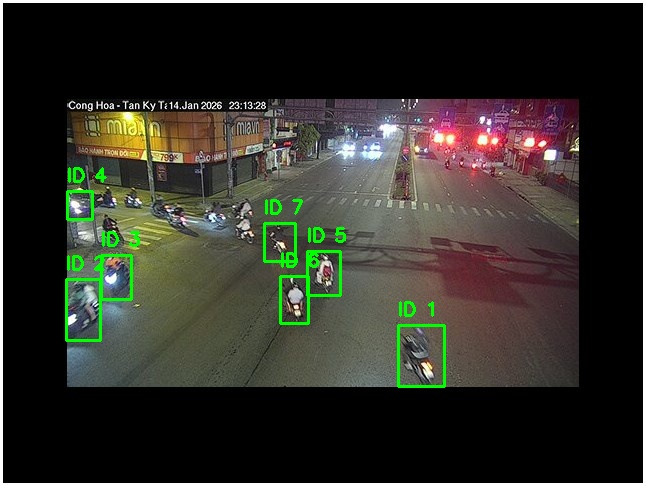

In [2]:
import cv2
import supervision as sv
from inference_sdk import InferenceHTTPClient
from deep_sort_realtime.deepsort_tracker import DeepSort
from tqdm import tqdm
import os
from dotenv import load_dotenv
from IPython.display import Image, display

load_dotenv()
API_KEY = os.getenv("ROBOFLOW_API_KEY")

# ===== 1. Init =====
CLIENT = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key=API_KEY
)

tracker = DeepSort(max_age=30)

IMAGE_PATH = "/workspaces/Model_AITRAFFIC/img_0.jpg"
result = CLIENT.infer(IMAGE_PATH, model_id="annonate_datatftphcm/1")

# ===== 2. Load image =====
image = cv2.imread(IMAGE_PATH)
image_height, image_width, _ = image.shape

# ===== 3. Parse predictions =====
all_predictions = []

if 'predictions' in result and isinstance(result['predictions'], dict):
    for class_name, preds_list in result['predictions'].items():
        for pred in preds_list:
            if 'class' not in pred:
                pred['class'] = class_name
            all_predictions.append(pred)

elif 'predictions' in result and isinstance(result['predictions'], list):
    all_predictions = result['predictions']

# ===== 4. Convert to supervision =====
roboflow_formatted_result = {
    "predictions": all_predictions,
    "image": {
        "width": image_width,
        "height": image_height
    }
}

detections = sv.Detections.from_inference(roboflow_formatted_result)

# ===== 5. Convert sang DeepSORT format =====
ds_detections = []

for xyxy, conf, class_name in zip(
    detections.xyxy,
    detections.confidence,
    detections.data['class_name']
):
    x1, y1, x2, y2 = xyxy
    w = x2 - x1
    h = y2 - y1

    ds_detections.append(([x1, y1, w, h], conf, class_name))

print("Số detections:", len(ds_detections))

# ===== 6. Fake nhiều frame =====
annotated_image = image.copy()

NUM_FRAMES = 20  # số frame giả

for i in tqdm(range(NUM_FRAMES), desc="Tracking Progress"):
    tracks = tracker.update_tracks(ds_detections, frame=image)

# ===== 7. Vẽ kết quả cuối =====
for track in tracks:
    track_id = track.track_id
    l, t, r, b = track.to_ltrb()

    cv2.rectangle(annotated_image, (int(l), int(t)), (int(r), int(b)), (0,255,0), 2)
    cv2.putText(
        annotated_image,
        f"ID {track_id}",
        (int(l), int(t - 10)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0,255,0),
        2
    )

# ===== 8. Lưu =====
output_path = "tracking_output.jpg"
cv2.imwrite(output_path, annotated_image)

print(f"Done! Saved at {output_path}")

display(Image(filename=output_path))

# **Render output với Conf bằng 20%**

In [5]:
from inference_sdk import InferenceHTTPClient

from IPython.display import Image, display

# 1. Khởi tạo Client Roboflow
CLIENT = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key=API_KEY
)

# 2. Chạy nhận diện trên ảnh cục bộ
# Lưu ý: "img_0.jpg" phải nằm cùng thư mục với file python này
IMAGE_PATH = "img_0.jpg"
# result = CLIENT.infer(IMAGE_PATH, model_id="annonate_datatftphcm/1")

result = CLIENT.run_workflow(
    workspace_name="tphcmdatatraffic",
    workflow_id="detect-count-and-visualize-2",
    images={
        "image": IMAGE_PATH # Path to your image file
    },
    parameters={
        "confidence": 0.4,
        "hide_labels": True,
        "box_opacity": 0.3
    },
    use_cache=True # Speeds up repeated requests
)
print(result)

[{'count_objects': 10, 'output_image': '...', 'predictions': {'image': {'width': 646, 'height': 486}, 'predictions': [{'width': 47.0, 'height': 61.0, 'x': 421.5, 'y': 355.5, 'confidence': 0.7737004160881042, 'class_id': 2, 'class': 'motorbike', 'detection_id': 'f030c0aa-73e0-4800-ad4b-bdbf46b8431f', 'parent_id': 'image'}, {'width': 35.0, 'height': 61.0, 'x': 83.5, 'y': 309.5, 'confidence': 0.7627608776092529, 'class_id': 2, 'class': 'motorbike', 'detection_id': '787520bf-23aa-471b-ad9b-e13ab94a6162', 'parent_id': 'image'}, {'width': 31.0, 'height': 44.0, 'x': 116.5, 'y': 277.0, 'confidence': 0.6656388640403748, 'class_id': 2, 'class': 'motorbike', 'detection_id': 'c874e83a-ad07-44e1-9453-f40e2b8db9f9', 'parent_id': 'image'}, {'width': 26.0, 'height': 28.0, 'x': 80.0, 'y': 205.0, 'confidence': 0.6112786531448364, 'class_id': 1, 'class': 'car', 'detection_id': 'ce46b102-502f-4c70-a7a4-95cb8be2f678', 'parent_id': 'image'}, {'width': 32.0, 'height': 44.0, 'x': 324.0, 'y': 273.0, 'confidenc

Đã lưu ảnh thành công!


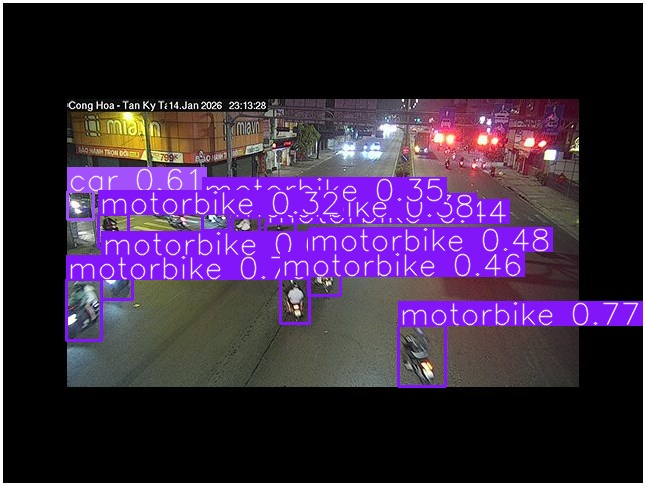

Tổng số phương tiện được nhận diện là: 10


In [6]:
import base64

# 1. Kiểm tra và lấy data_node
if isinstance(result, list) and len(result) > 0:
    data_node = result[0]
else:
    data_node = result

try:
    # 2. Truy cập trực tiếp vào 'output_image'
    base64_str = data_node.get('output_image')
    count_objects = data_node.get('count_objects')
    if base64_str:
        # Giải mã và lưu file
        img_data = base64.b64decode(base64_str)
        output_path = "ket_qua_output.jpg"
        with open(output_path, "wb") as fh:
            fh.write(img_data)
        print("Đã lưu ảnh thành công!")

        try:
            display(Image(filename=output_path))
            print(f"Tổng số phương tiện được nhận diện là: {count_objects}")
        except FileNotFoundError:
            print(f"Lỗi: Không tìm thấy file ảnh tại {output_path}. Vui lòng đảm bảo bạn đã chạy cell lưu ảnh trước đó.")
        except Exception as e:
            print(f"Đã xảy ra lỗi khi hiển thị ảnh: {e}")

    else:
        print("Không tìm thấy dữ liệu ảnh trong node.")

except Exception as e:
    print(f"Lỗi khi xử lý ảnh: {e}")